# Visualize NWM



## Load model


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4"

In [2]:
import yaml
import torch
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
from PIL import Image, ImageDraw
import requests
from io import BytesIO
import numpy as np
from IPython.display import display, HTML
import ipywidgets as widgets
from diffusers.models import AutoencoderKL

from diffusion import create_diffusion
from isolated_nwm_infer_v6 import model_forward_wrapper
from misc import transform
from models_zwc_v6 import CDiT_models
from datasets_v3 import TrainingDataset

EXP_NAME = 'nwm_cdit_airvln_16'
NAME = 'nwm_cdit_airvln_v6'
MODEL_PATH = f'logs/{NAME}/checkpoints/0200000.pth.tar'

with open("config/data_config.yaml", "r") as f:
    default_config = yaml.safe_load(f)
config = default_config

with open(f'config/{EXP_NAME}.yaml', "r") as f:
    user_config = yaml.safe_load(f)
config.update(user_config)
latent_size = config['image_size'] // 8

print("loading model")
model = CDiT_models[config['model']](input_size=latent_size, context_size=config['context_size'] + 1)
ckp = torch.load(MODEL_PATH, map_location='cpu', weights_only=False) 

print(model.load_state_dict(ckp["ema"], strict=True))
model.eval()
device = 'cuda:0'
model.to(device)
model = torch.compile(model)

diffusion = create_diffusion(str(250))
vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-ema").to(device)
latent_size = config['image_size'] // 8



loading model
<All keys matched successfully>


## Choose starting image

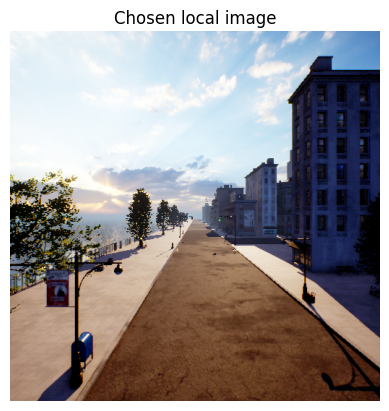

In [3]:
local_image_path = '/data1/tpz/nwm-main/data/airvln_16/3A3KKYU7QBF7NLUJ5LVEB19F5RQMW4_processed'
index = 0

def load_and_show_local_image(path):
    img = Image.open(path)
    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis('off')
    plt.title("Chosen local image")
    plt.show()
    from torchvision import transforms
    _transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True),
    ])
    
    x_start = _transform(img)
    return x_start.unsqueeze(0).expand(config['context_size'], x_start.shape[0], x_start.shape[1], x_start.shape[2])

x_start = load_and_show_local_image(local_image_path + f'/{index}.jpg')

In [4]:
import pickle
with open(os.path.join(local_image_path, "traj_data.pkl"), "rb") as f:
    traj_data = pickle.load(f)
for k,v in traj_data.items():
    traj_data[k] = v.astype('float')
K = traj_data["K"]
depth_map = traj_data["depth"][index]
print(K)

[[256.   0. 256.]
 [  0. 256. 256.]
 [  0.   0.   1.]]


## Visualize navigation commands

In [5]:
from project_functions import reproject_depth_to_other_pose, project_to_2d_image, resize_image_half
import cv2

def generate_augmented_image(K, depth_map, rgb_img, pose_src, pose_dst) -> np.ndarray:
    """
    基于深度图 + pose 生成从另一个相机视角观察到的图像。
    """
    dep_image_size = depth_map.shape  # (H, W)
    # print(dep_image_size)
    # print(rgb_img.shape)
    if rgb_img.shape[:2] != dep_image_size:
        H_rgb, W_rgb = rgb_img.shape[:2]
        depth_map = cv2.resize(depth_map, (W_rgb, H_rgb), interpolation=cv2.INTER_NEAREST)
    # print(depth_map.shape)
    points_3d, colors = reproject_depth_to_other_pose(K, depth_map, rgb_img, pose_src, pose_dst) 
    images = project_to_2d_image(K, points_3d, colors, depth_map.shape) # (H, W, 3)
    return images

def pose_vec_to_mat(pos):
    """
    Convert (x, y, z, yaw) to 4x4 transformation matrix
    """
    x, y, z, yaw = pos
    cos_yaw = np.cos(yaw)
    sin_yaw = np.sin(yaw)

    # Rotation around Z axis (yaw only)
    R = np.array([
        [cos_yaw, -sin_yaw, 0],
        [sin_yaw,  cos_yaw, 0],
        [0,        0,       1]
    ])

    t = np.array([[x], [y], [z]])

    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3:] = t

    return T

In [6]:
def update_position(last_pos, command):
    x, y, z, heading = last_pos
    if command == 'Forward':
        x += np.cos(heading)
        y += np.sin(heading)
    elif command == 'Back':
        x -= np.cos(heading)
        y -= np.sin(heading)
    elif command == 'Rotate Left':
        heading += 0.5 /(np.pi / 2)
    elif command == 'Rotate Right':
        heading -= 0.5 /(np.pi / 2)
    elif command == 'Up':
        z += 1
    elif command == 'Down':
        z -= 1
    heading = (heading + np.pi) % (2 * np.pi) - np.pi  # 保证在[-π, π]
    return (x, y, z, heading)

In [7]:
import random
from matplotlib import pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import gridspec
from torchvision.utils import save_image

In [8]:
def is_valid_sequence(seq):
    last_movement = None

    for cmd in seq:
        if cmd == 'Back':
            return False

        if cmd in ['Up', 'Down']:
            if last_movement == 'Up' and cmd == 'Down':
                return False
            if last_movement == 'Down' and cmd == 'Up':
                return False
            last_movement = cmd
        elif cmd == 'Forward':
            last_movement = 'Forward'

    return True

def sample_valid_sequence(commands_names, length):
    while True:
        seq = random.choices(commands_names, k=length)
        if is_valid_sequence(seq):
            return seq
         
def sample_valid_sequence_from_template(command_names, length):
    templates = {
        "起飞后巡航": ['Up', 'Forward', 'Forward', 'Rotate Left', 'Forward', 'Forward', 'Down'],
        "螺旋拉升": ['Up', 'Forward', 'Rotate Right', 'Forward', 'Rotate Right', 'Forward', 'Up', 'Forward', 'Down', 'Down'],
        "Z字前进": ['Up', 'Forward', 'Rotate Left', 'Forward', 'Rotate Right', 'Forward', 'Rotate Left', 'Forward', 'Down'],
        "升空打点后降落": ['Up', 'Forward', 'Forward', 'Down'],
        "高低穿越": ['Up', 'Forward', 'Up', 'Forward', 'Down', 'Forward', 'Down'],
    }

    mode_name, base_seq = random.choice(list(templates.items()))
    print(f"选中飞行模式：{mode_name}")

    # 计算开头 Up 和结尾 Down 的数量
    up_count = 0
    while up_count < len(base_seq) and base_seq[up_count] == 'Up':
        up_count += 1

    down_count = 0
    while down_count < len(base_seq) and base_seq[-(down_count + 1)] == 'Down':
        down_count += 1

    head = base_seq[:up_count]
    tail = ['Down'] * up_count  # 强制 Down 数量 == Up 数量
    core_seq = base_seq[up_count:len(base_seq)-down_count]

    core_len = length - len(head) - len(tail)
    if core_len < 0:
        raise ValueError("Sequence length too short for given template structure.")

    repeats = core_len // len(core_seq)
    remainder = core_len % len(core_seq)
    middle = core_seq * repeats + core_seq[:remainder]

    return head + middle + tail

选中飞行模式：螺旋拉升
0


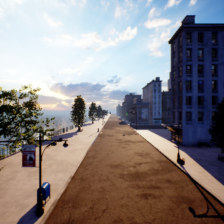

Output()

Step 1/12: Up
x_cond shape: torch.Size([1, 4, 3, 224, 224])
x_all shape: torch.Size([1, 5, 3, 224, 224])


  0%|          | 0/250 [00:00<?, ?it/s]

TorchRuntimeError: Failed running call_function <built-in function add>(*(FakeTensor(..., device='cuda:0', size=(1, 6, 196, 1152), dtype=torch.bfloat16), FakeTensor(..., device='cuda:0', size=(5, 196, 1152), requires_grad=True)), **{}):
Attempting to broadcast a dimension of length 5 at -3! Mismatching argument at index 1 had torch.Size([5, 196, 1152]); but expected shape should be broadcastable to [1, 6, 196, 1152]

from user code:
   File "/data1/tpz/nwm-main/models_zwc_v6.py", line 252, in forward
    x_cond = self.x_embedder(x_cond.flatten(0, 1)).unflatten(0, (x_cond.shape[0], x_cond.shape[1])) + self.pos_embed[:self.context_size]  # (N, T, D), where T = H * W / patch_size ** 2.flatten(1, 2)      [B*num_goals, num_cond+1, 196, 1152]

Set TORCH_LOGS="+dynamo" and TORCHDYNAMO_VERBOSE=1 for more information


You can suppress this exception and fall back to eager by setting:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True


In [9]:
commands = {
    'Forward': [1,0,0,0],
    'Rotate Right': [0,0,0,0.5],
    'Rotate Left': [0,0,0,-0.5],
    'Back': [-1,0,0,0],
    'Up': [0,0,-1,0],
    'Down': [0,0,1,0],
}# （dx, dy, dz, dθ）
command_names = list(commands.keys())
trajectory = [(0.0, 0.0, 0.0, np.pi/2)]  # 初始位置和朝上方向（π/2）
preds = {}

def reset():
    global trajectory
    x_cond_pixels = x_start
    reconstructed_image=x_cond_pixels.to(device)
    preds['x_cond_pixels_display'] = (reconstructed_image[-1] * 127.5 + 127.5).clamp(0, 255).permute(1, 2, 0).to("cpu", dtype=torch.uint8).numpy()
    preds['x_cond_pixels'] = x_cond_pixels
    preds['video'] = [preds['x_cond_pixels_display']]
    trajectory = [(0.0, 0.0, 0.0, np.pi/2)] 

for idx in range(10):   
    auto_sequence = sample_valid_sequence_from_template(command_names, 12)

    # 设置保存目录
    save_dir = "./results"
    os.makedirs(save_dir, exist_ok=True)

    # 重置环境
    reset()
    print(idx)
    display(Image.fromarray(preds['x_cond_pixels_display']))

    output = widgets.Output()
    display(output)
    rel_t = (torch.ones(1)*0.0078125).to(device)

    # 循环执行动作序列
    for step, action in enumerate(auto_sequence):
        print(f"Step {step+1}/{len(auto_sequence)}: {action}")
        y = torch.tensor(commands[action]).to(device).unsqueeze(0)
        
        last_pos = trajectory[-1]
        new_pos = update_position(last_pos, action)
        trajectory.append(new_pos)

        x_cond_pixels = preds['x_cond_pixels'][-4:].unsqueeze(0).to(device)
        rgb_img_tensor = preds['x_cond_pixels'][-1].cpu()
        rgb_img_numpy = rgb_img_tensor.to(torch.float32).permute(1, 2, 0).numpy()
        pose_src = pose_vec_to_mat(last_pos)
        pose_dst = pose_vec_to_mat(new_pos)

        x_supervised = generate_augmented_image(K=K, depth_map=depth_map, rgb_img=rgb_img_numpy, pose_src=pose_src, pose_dst=pose_dst)
        x_supervised = torch.from_numpy(x_supervised).permute(2, 0, 1).unsqueeze(0).unsqueeze(0).float().to(device)

        x_all = torch.cat((x_cond_pixels, x_supervised), dim=1) 
        print(f"x_cond shape: {x_cond_pixels.size()}")
        print(f"x_all shape: {x_all.size()}")
        samples = model_forward_wrapper((model, diffusion, vae), x_all, y, None, latent_size, device, config["context_size"], num_goals=1, rel_t=rel_t, progress=True, x_supervised=x_supervised)
        x_cond_pixels = samples
        preds['x_cond_pixels'] = torch.cat([preds['x_cond_pixels'].to(x_cond_pixels), x_cond_pixels], dim=0)

        samples_img = (samples * 127.5 + 127.5).permute(0, 2, 3, 1).clamp(0,255).to("cpu", dtype=torch.uint8).numpy()
        img = Image.fromarray(samples_img[0])
        draw = ImageDraw.Draw(img)
        draw.text((10, 10), f"Step {step+1}: {action}", fill=(255, 0, 0))

        # img.save(os.path.join(save_dir, f"frame_{step:03d}.png"))
        preds['video'].append(np.array(img))

    print("All frames saved!")

    # ----- 视频生成 -----

    video = np.array(preds['video'])
    positions = trajectory

    xs = [p[0] for p in positions]
    ys = [p[1] for p in positions]
    zs = [p[2] for p in positions]
    thetas = [p[3] for p in positions]

    fig = plt.figure(figsize=(12, 6))
    fig.suptitle("Sequence: " + " | ".join(auto_sequence), fontsize=12)
    plt.subplots_adjust(top=0.85)

    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5])
    ax1 = fig.add_subplot(gs[0])
    im1 = ax1.imshow(video[0])
    ax1.axis('off')
    ax1.set_title("Generated View")

    ax2 = fig.add_subplot(gs[1], projection='3d')
    ax2.set_title("3D Trajectory")
    margin = 1
    ax2.set_xlim(min(xs) - margin, max(xs) + margin)
    ax2.set_ylim(min(ys) - margin, max(ys) + margin)
    ax2.set_zlim(min(zs) - margin, max(zs) + margin)
    traj_line, = ax2.plot([], [], [], 'bo-', lw=2)
    arrow = ax2.quiver(xs[0], ys[0], zs[0], np.cos(thetas[0]), np.sin(thetas[0]), 0, length=1.0, normalize=True, color='red')

    def init():
        im1.set_data(video[0])
        traj_line.set_data([], [])
        traj_line.set_3d_properties([])
        return im1, traj_line, arrow

    def animate(i):
        global arrow
        im1.set_data(video[i])
        traj_line.set_data(xs[:i+1], ys[:i+1])
        traj_line.set_3d_properties(zs[:i+1])
        try:
            arrow.remove()
        except Exception:
            pass
        dx = np.cos(thetas[i])
        dy = np.sin(thetas[i])
        dz = 0
        arrow = ax2.quiver(xs[i], ys[i], zs[i], dx, dy, dz, length=1.0, normalize=True, color='red')
        return im1, traj_line, arrow

    num_frames = min(len(video), len(positions))
    anim = animation.FuncAnimation(fig, animate, init_func=init,
                                frames=num_frames, interval=500, blit=False)

    video_path = os.path.join(save_dir, f"output{idx}.mp4")
    anim.save(video_path, writer='ffmpeg', fps=2)
    print(f"Video saved at {video_path}")